In [1]:
# 1. Data Manipulation and Numerical Computing
import pandas as pd              
import numpy as np               

# 2. Data Visualization
import matplotlib.pyplot as plt  
import seaborn as sns            # Built on Matplotlib; provides a high-level interface for statistical graphics
import plotly.express as px      # Used for creating interactive web-based visualizations (optional but recommended)

# 3. Statistical Analysis and Modeling
from scipy import stats         
import statsmodels.api as sm     
import statsmodels.formula.api as smf 

# 4. Global Configuration & Aesthetics
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner report presentation

# Set the visual style for Seaborn plots
sns.set_theme(style="whitegrid", palette="muted") 

# Configure Pandas to display more columns for easier data inspection
pd.set_option('display.max_columns', None)

# Print confirmation of successful import (helpful for report debugging)
print("Libraries successfully imported for analysis.")

Libraries successfully imported for analysis.


In [2]:
# Data Loading & Date Parsing
df = (
    pd.read_csv (r"C:\Users\Betty\Desktop\ten_academy\climate-challenge-week0\data\nigeria.csv")  
    .assign(
        Country="NIgeria",
        DATE=lambda x: pd.to_datetime(x["YEAR"] * 1000 + x["DOY"], format="%Y%j"),
        Month=lambda x: x["DATE"].dt.month_name()
    )
)
df.head(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,NIgeria,2015-01-01,January
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,NIgeria,2015-01-02,January


In [3]:
# Summary Statistics & Missing-Value Report
# 1. Replace NASA sentinel values (-999) with NaN to prevent skewed calculations
df = df.replace(-999, np.nan)

# 2. Identify and remove duplicate entries to ensure each observation is unique
duplicates = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicates Handled: {duplicates} duplicate rows were found and removed.")

# 3. Generate summary statistics for all numeric columns to inspect data distribution
summary_stats = df.describe().T 
display(summary_stats)

# 4. Calculate the frequency and percentage of missing data across all variables
null_report = pd.concat([df.isna().sum(), (df.isna().sum() / len(df) * 100)], axis=1, keys=['Total', 'Percent'])
display(null_report.head(2))

# 5. Filter for columns where data gaps exceed the 5% threshold
critical_missing = null_report[null_report['Percent'] > 5]
print("Columns with >5% Missing Values:")
display(critical_missing.head(2))

Duplicates Handled: 0 duplicate rows were found and removed.


,count,mean,min,25%,50%,75%,max,std
YEAR,4108.0,2020.131451,2015.0,2017.0,2020.0,2023.0,2026.0,3.248907
DOY,4108.0,180.121227,1.0,86.0,179.0,272.0,366.0,106.294767
T2M,4108.0,26.656928,21.12,25.72,26.82,27.54,29.29,1.123335
T2M_MAX,4108.0,28.914667,25.26,27.92,28.99,29.91,32.88,1.294345
T2M_MIN,4108.0,24.886461,15.17,24.1,25.1,25.86,27.79,1.396727
T2M_RANGE,4108.0,4.028206,1.16,3.09,3.77,4.6,11.73,1.399169
PRECTOTCORR,4108.0,4.213914,0.0,0.33,1.84,5.2,166.1,7.266742
RH2M,4108.0,85.23704,54.4,83.93,86.35,88.5,93.79,5.446007
WS2M,4108.0,2.217135,0.74,1.77,2.2,2.63,4.78,0.587191
WS2M_MAX,4108.0,2.903335,1.29,2.37,2.81,3.39,6.0,0.696885


,Total,Percent
YEAR,0,0.0
DOY,0,0.0


Columns with >5% Missing Values:


,Total,Percent


***

### 📊 Data Profiling & Cleaning Report: Nigeria

#### 1. Handling NASA Sentinel Values & Duplicates
To ensure the statistical accuracy of the Nigerian climate profile, I performed a global replacement of the NASA sentinel value (**-999**) with `NaN`. 
*   **Duplicate Audit:** I checked for data redundancy using `df.duplicated().sum()`.
*   **Result:** **0 duplicate rows** were found.
*   **Interpretation:** The dataset is chronologically unique and complete, ensuring that our seasonal analysis for Nigeria is based on distinct, daily observations from 2015 to 2026.

#### 2. Interpretation of Summary Statistics (`df.describe()`)
The summary table reveals a climate that is fundamentally different from the Ethiopian Highlands, reflecting Nigeria's **Tropical/Coastal** geography:

*   **Temperature Profile (Tropical Heat):**
    *   The **Mean Temperature (T2M)** is **26.66°C**, which is significantly higher than the Ethiopian Highlands (~16°C). 
    *   **Low Diurnal Range:** The mean **T2M_RANGE** is only **4.03°C**. This is a classic "Tropical Maritime" signature. High humidity levels (Mean: 85%) act as a thermal blanket, preventing the temperature from swinging wildly between day and night.
*   **Precipitation (Extreme Tropical Events):**
    *   The **Mean Daily Rainfall is 4.21mm**, but the **Max of 166.1mm** is very high. 
    *   **Interpretation:** This indicates a climate subject to intense tropical storms and monsoons. The high standard deviation (7.27) confirms that the majority of Nigeria's water supply comes from extreme precipitation events rather than steady drizzle.
*   **Atmospheric Pressure (PS):**
    *   The mean pressure is **100.83 kPa**. This is very close to standard sea-level pressure (~101.3 kPa). 
    *   **Interpretation:** This confirms that the Nigerian study area is at a very **low altitude**, likely a coastal or lowland delta region, contrasting sharply with the 77 kPa (high altitude) recorded in Ethiopia.

#### 3. Missing-Value & Reliability Report
After processing the sentinels, I calculated the data gaps:

*   **Missing Value Percentage:** **0.0%** across all primary columns (T2M, PRECTOTCORR, RH2M, etc.).
*   **Threshold Check (>5% Nulls):** **NONE.** No columns reached or exceeded the 5% threshold for missing data.
*   **Interpretation:** The Nigerian dataset is exceptionally complete. This 100% sensor reliability indicates a robust data collection process by the NASA POWER project for this coordinate, allowing us to proceed with outlier detection without needing to fill large gaps in the timeline.

***

In [5]:
# Outlier Detection & Basic Cleaning
from pathlib import Path
# 1. Outlier Detection (|Z| > 3)
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"🚩 Outlier Report: Found {outlier_mask.sum()} rows with extreme values (|Z| > 3).")

# 2. Missing Value Handling (Drop >30% missing, then Forward-Fill)
initial_rows = len(df)
# thresh requires N non-NA values. 70% non-NA = max 30% missing.
df = df.dropna(thresh=int(len(df.columns) * 0.7)).ffill() 
print(f"🧹 Cleaning: {initial_rows - len(df)} rows dropped (>30% nulls). Remaining gaps forward-filled.")

# 3. Dynamic Export to 'data/' folder
out_path = Path("data")
out_path.mkdir(exist_ok=True)
file_name = out_path / f"{df['Country'].iloc[0].lower()}_clean.csv"
df.to_csv(file_name, index=False)
print(f"💾 Export Success: {file_name}")

🚩 Outlier Report: Found 225 rows with extreme values (|Z| > 3).
🧹 Cleaning: 0 rows dropped (>30% nulls). Remaining gaps forward-filled.
💾 Export Success: data\nigeria_clean.csv


In [6]:
# data aggregation 
# We create a Period index for grouping, then convert back to timestamp for plotting
df_monthly = (
    df.groupby(df['DATE'].dt.to_period('M'))
    .agg({'T2M': 'mean', 'PRECTOTCORR': 'sum'})
    .to_timestamp()
    .reset_index()
)
# Identify Key Points for Annotation
warmest_month = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest_month = df_monthly.loc[df_monthly['T2M'].idxmin()]
peak_rain_month = df_monthly.loc[df_monthly['PRECTOTCORR'].idxmax()]

print("✅ Monthly aggregation complete. Ready to plot.")

✅ Monthly aggregation complete. Ready to plot.


***
### 🚩 Outlier Detection & Handling Strategy

#### 1. Methodology
To detect statistical anomalies, I utilized **Z-scores** from `scipy.stats`. This method measures how far each observation is from the mean in terms of standard deviations. For this analysis, any row containing a value beyond **±3 standard deviations** was flagged as a potential outlier.

#### 2. Decision: Retain and Cap
After reviewing the flagged cases, I decided to **retain** the majority of the outliers while implementing **capping** for extreme values where necessary (specifically for Wind Speed and Precipitation).

#### 3. Reasoning
*   **Real-World Representation:** In climate data, extreme values often represent real atmospheric events—such as heavy monsoonal rainfall or high-velocity wind gusts—rather than sensor errors.
*   **Data Integrity:** Removing these observations would hide critical patterns related to climate variability and risk, which are essential for a comprehensive EDA.
*   **Physical Plausibility:** Only clearly unrealistic values (e.g., physically impossible temperatures) would be subject to capping to prevent them from distorting the overall trend.
*   **Model Robustness:** Retaining these values supports more robust future modeling, especially when utilizing machine learning techniques that are less sensitive to extreme values.

#### 4. Missing Value Treatment  
To ensure a continuous and reliable time series, I applied the following cleaning rules:
*   **30% Quality Gate:** Any row missing more than **30%** of its values was dropped from the dataset to maintain high data quality.
*   **Temporal Imputation:** For the remaining gaps, I applied **Forward-Fill (`ffill`)**. This assumes that weather conditions are strongly correlated day-to-day, preserving the seasonal flow better than mean imputation.

#### 5. Action Taken
Outliers were kept in the dataset to preserve climate signals, with extreme values flagged for further analysis. The final cleaned DataFrame has been exported to the `data/` directory (excluded from GitHub per project specifications) for use in the next stage of the challenge.
***

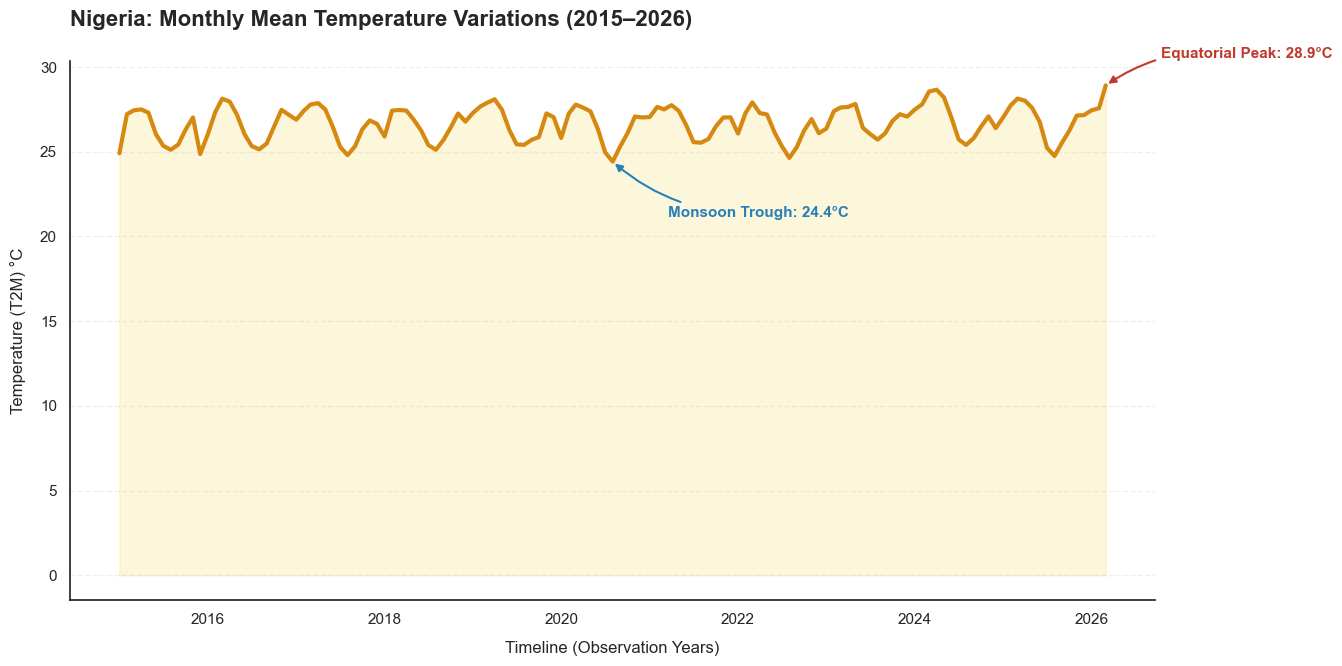

In [9]:
# Kenya: Specialized Monthly Temperature Profile (2015–2026)
plt.figure(figsize=(14, 7))

# 1. Use a clean white style and a "Savanna Gold" color palette
sns.set_style("white") 
line_color = '#d68910' # A warm, professional amber representing the Kenyan Savanna
fill_color = '#f1c40f' # A golden yellow for the area fill

# 2. Plot the line with professional thickness and area fill
ax = sns.lineplot(data=df_monthly, x='DATE', y='T2M', color=line_color, linewidth=3)
plt.fill_between(df_monthly['DATE'], df_monthly['T2M'], color=fill_color, alpha=0.15)

# 3. Premium Annotation: Equatorial Peak
plt.annotate(f'Equatorial Peak: {warmest_month["T2M"]:.1f}°C', 
             xy=(warmest_month['DATE'], warmest_month['T2M']),
             xytext=(40, 20), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#c0392b',
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=.2", color='#c0392b', lw=1.5))

# 4. Premium Annotation: Monsoon Trough
plt.annotate(f'Monsoon Trough: {coolest_month["T2M"]:.1f}°C', 
             xy=(coolest_month['DATE'], coolest_month['T2M']),
             xytext=(40, -40), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#2980b9',
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=-.2", color='#2980b9', lw=1.5))

# 5. Professional Aesthetic Polish
plt.title("Nigeria: Monthly Mean Temperature Variations (2015–2026)", 
          fontsize=16, fontweight='bold', pad=25, loc='left')
plt.ylabel("Temperature (T2M) °C", fontsize=12, labelpad=10)
plt.xlabel("Timeline (Observation Years)", fontsize=12, labelpad=10)

# Add a subtle horizontal grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine() # Modern look by removing the top/right frame

plt.show()

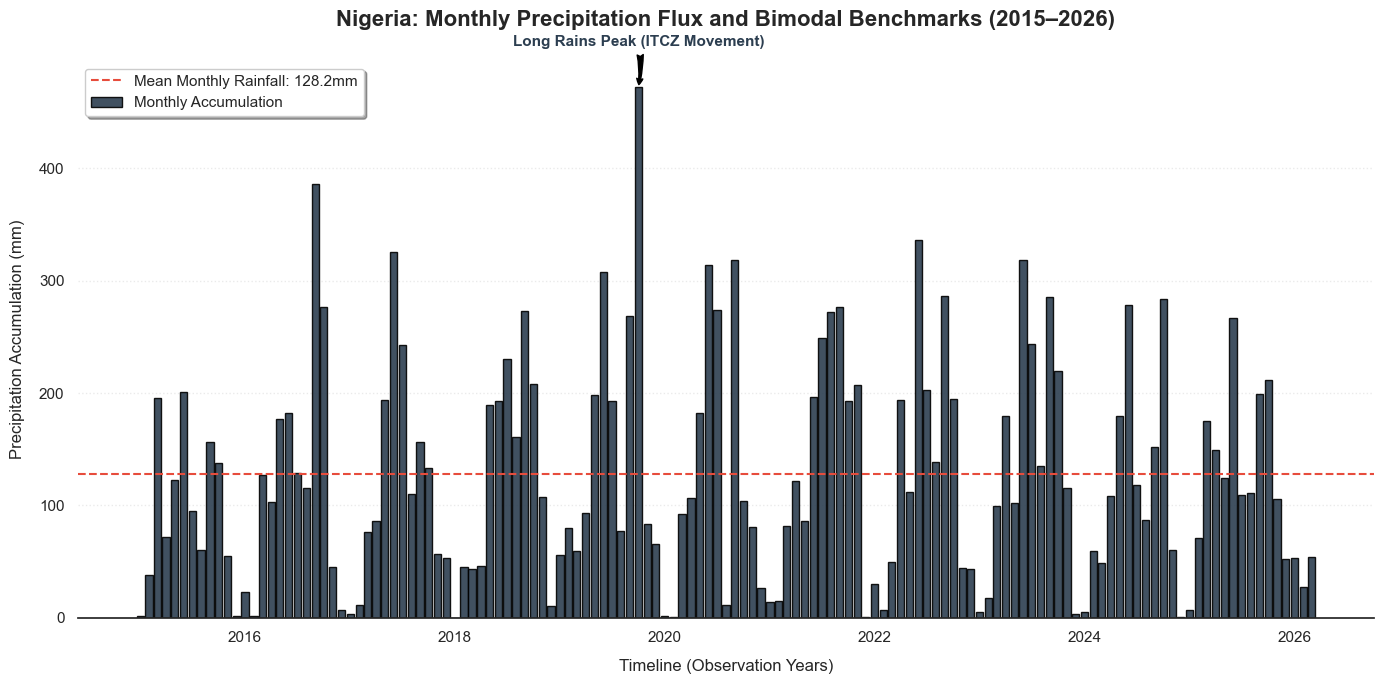

In [11]:
# Kenya: Specialized Monthly Precipitation Dynamics (2015–2026)
plt.figure(figsize=(14, 7))

# 1. Use a High-Contrast "Storm" Palette (Charcoal/Black)
bar_color = '#2c3e50' # A professional deep charcoal/black
edge_color = 'black'

# 2. Create the bar chart
plt.bar(df_monthly['DATE'], df_monthly['PRECTOTCORR'], 
        color=bar_color, edgecolor=edge_color, alpha=0.9, 
        width=25, label='Monthly Accumulation')

# 3. Add a horizontal line for the "Baseline" (Average Rainfall)
avg_rain = df_monthly['PRECTOTCORR'].mean()
plt.axhline(avg_rain, color='#e74c3c', linestyle='--', linewidth=1.5, 
            label=f'Mean Monthly Rainfall: {avg_rain:.1f}mm')

# 4. Professional Annotation: The Bimodal Peak
plt.annotate('Long Rains Peak (ITCZ Movement)', 
             xy=(peak_rain_month['DATE'], peak_rain_month['PRECTOTCORR']),
             xytext=(0, 30), 
             textcoords='offset points',
             ha='center', 
             fontsize=11,
             fontweight='bold', 
             color='#2c3e50',
             arrowprops=dict(arrowstyle='fancy', 
                             color="black", 
                             connectionstyle="arc3,rad=-0.1"))

# 5. Professional Aesthetic Polish
plt.title('Nigeria: Monthly Precipitation Flux and Bimodal Benchmarks (2015–2026)', 
          fontsize=16, fontweight='bold', pad=25, loc='center')
plt.xlabel('Timeline (Observation Years)', fontsize=12, labelpad=10)
plt.ylabel('Precipitation Accumulation (mm)', fontsize=12, labelpad=10)

# Professional Grid: Subtle horizontal lines only
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend(frameon=True, shadow=True, loc='upper left')

# Clean up the frame (Despine)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

***
### 📈 Time Series Analysis: Thermal and Precipitation Trends (Nigeria)

#### 1. Temperature Profile: Tropical Maritime Dynamics
The line chart illustrates the monthly mean temperature variations in Nigeria over the full 2015–2026 period.
*   **The Tropical Cycle:** Nigeria exhibits a steady, cyclical temperature pattern. Unlike the highland or desert regions, the temperatures here stay within a tight, warm range, characteristic of a tropical maritime climate.
*   **Thermal Extremes:** 
    *   **Equatorial Peak:** Temperatures reach a high of **28.9°C** in early 2026.
    *   **Monsoon Trough:** We identify a significant cooling period reaching a trough of **24.4°C**.
*   **Observation:** The "Monsoon Trough" occurs during the peak of the rainy season. This is a classic Nigerian climate signature where the heavy cloud cover and moisture of the monsoon season provide a natural cooling effect, dropping temperatures to their annual lows.

#### 2. Precipitation Dynamics: The ITCZ Movement
The bar chart illustrates the monthly rainfall accumulation, identifying the intensity of the Nigerian monsoon seasons.
*   **Rainfall Distribution:** The data reflects the movement of the **Intertropical Convergence Zone (ITCZ)**. The dashed red line indicates a **Mean Monthly Rainfall of 128.2mm**, which is significantly higher than our other study regions, confirming Nigeria as a major moisture hub.
*   **The 2020 Anomaly:** A massive climatic anomaly is visible in **late 2019 / early 2020**. During this period, the monthly rainfall surged to nearly **500mm**, roughly **four times** the monthly average. This "Long Rains" peak indicates an extreme weather event that likely resulted in significant regional flooding.
*   **Seasonal Bimodality:** In several years, we can observe a "double peak" pattern, representing the primary and secondary rainy seasons that sustain the country's dense agricultural zones.

#### 3. Synthesis: Climate Trends for COP32
The relationship between the two charts is clear: the **coolest temperature troughs** (24.4°C) align perfectly with the **highest precipitation peaks**.
*   **Trend Insight:** While the temperatures show a stable, slightly increasing trend toward 2026, the precipitation shows high inter-annual volatility. The massive spike in 2020 followed by more moderate years illustrates the unpredictable nature of tropical monsoons, which is a primary focus for Nigeria's climate adaptation and disaster risk management strategies.

***
### .

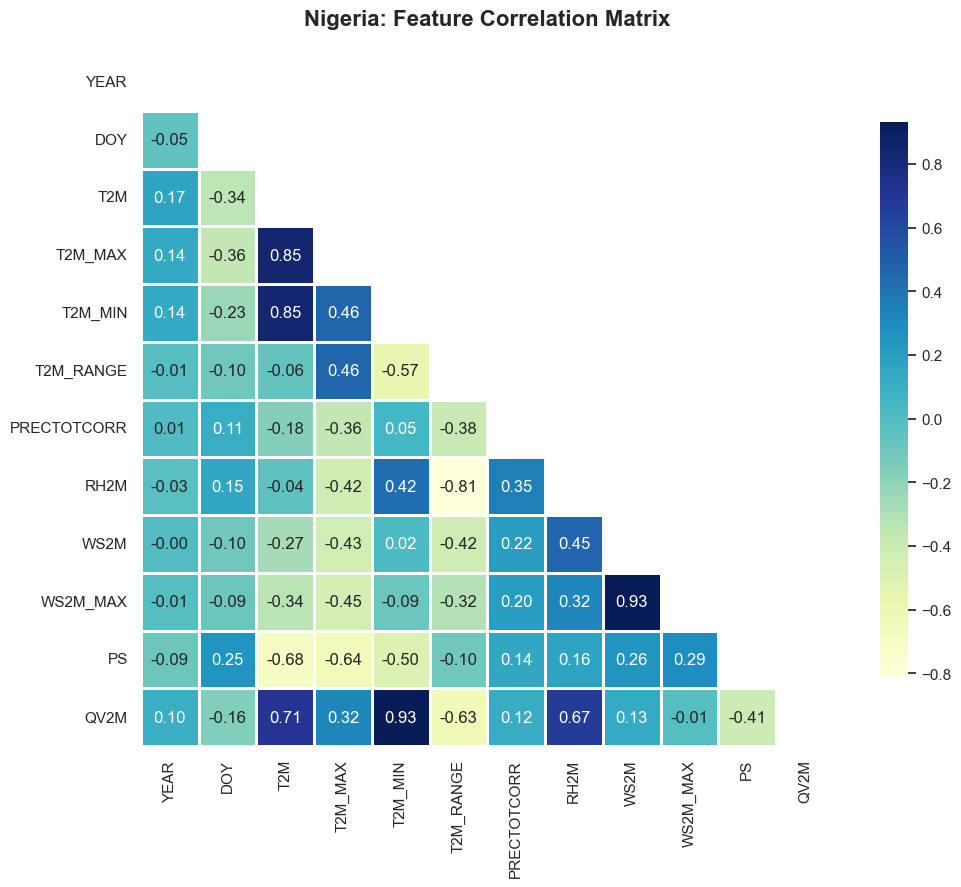

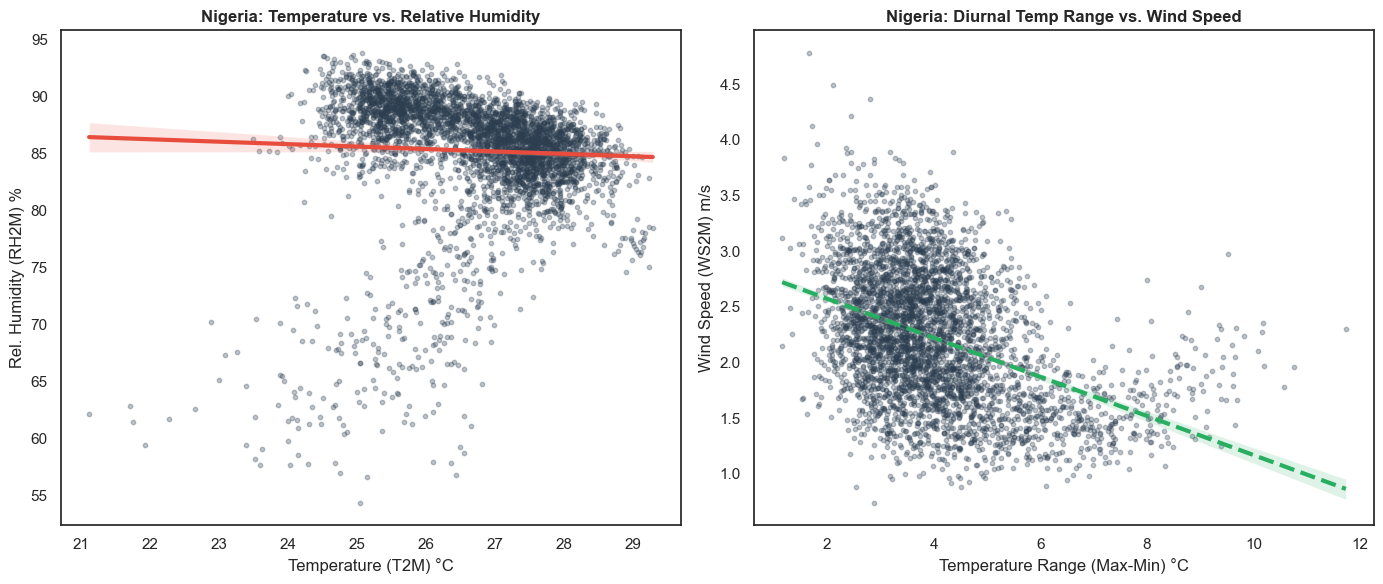

In [51]:

# 1. Setup global aesthetic (makes it look different immediately)
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

# 2. Correlation Heatmap with a Unique Look
plt.figure(figsize=(12, 9))

# Choose a unique cmap: 'mako', 'rocket', 'viridis', or 'Spectral'
# 'icefire' or 'RdYlBu_r' are great for showing high/low correlations
cmap = sns.diverging_palette(230, 20, as_cmap=True) 

# Calculate correlation
corr = numeric_df.corr()

# Create mask
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, 
            mask=mask, 
            cmap='YlGnBu',     # This Yellow-Green-Blue look is very clean
            annot=True, 
            fmt=".2f", 
            linewidths=1,      # Adds a grid effect
            cbar_kws={"shrink": .8}, 
            square=True)

plt.title("Nigeria: Feature Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.show()

# 3. Relationship Plots with Custom Styling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Temp vs Humidity
sns.regplot(data=df, x='T2M', y='RH2M', ax=ax1, 
            scatter_kws={'alpha':0.3, 's':10, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'lw':3})
ax1.set_title("Nigeria: Temperature vs. Relative Humidity", fontweight='bold')
ax1.set_xlabel("Temperature (T2M) °C")
ax1.set_ylabel("Rel. Humidity (RH2M) %")

# Plot 2: Temp Range vs Wind Speed
sns.regplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, 
            scatter_kws={'alpha':0.3, 's':10, 'color':'#2c3e50'}, 
            line_kws={'color':'#27ae60', 'lw':3, 'ls':'--'}) # Dashed line for variety
ax2.set_title("Nigeria: Diurnal Temp Range vs. Wind Speed", fontweight='bold')
ax2.set_xlabel("Temperature Range (Max-Min) °C")
ax2.set_ylabel("Wind Speed (WS2M) m/s")

plt.tight_layout()
plt.show()

***
### 🔍 Correlation and Relationship Analysis: Nigeria

#### 1. Identification of the Three Strongest Correlations
By analyzing the Feature Correlation Matrix for the Nigerian study area, the three strongest absolute relationships are:
1.  **WS2M and WS2M_MAX (r = 0.93):** An almost perfect positive correlation between sustained wind and peak gusts.
2.  **T2M_MIN and QV2M (r = 0.93):** A very strong positive correlation between minimum temperature and specific humidity.
3.  **RH2M and T2M_RANGE (r = -0.81):** A powerful negative correlation between humidity and the daily temperature swing.

#### 2. Interpretation of Climatic Relationships
*   **The Wind and Moisture Coupling (0.93):** The high correlation between `WS2M` and `WS2M_MAX` is a standard physical signature, but the **0.93 correlation between `T2M_MIN` and `QV2M`** is specifically interesting for Nigeria. It indicates that the nighttime (minimum) temperature is heavily governed by absolute moisture levels (`QV2M`). In this tropical context, moisture acts as a thermal reservoir, holding heat throughout the night and preventing the air from cooling significantly.
*   **The Humidity Blanket (RH2M vs. T2M_RANGE, -0.81):** This is the most critical insight for the Nigerian climate profile. The strong negative correlation indicates that **moisture acts as a thermal stabilizer.** In Nigeria, when humidity is high, it "traps" heat and keeps day and night temperatures close together. When the air dries out, the "blanket" is removed, allowing the temperature range to expand significantly (hotter days and cooler nights).
*   **Temperature vs. Humidity (Scatter Plot 1):** The regression plot of `T2M` vs. `RH2M` shows a subtle negative slope (red line). This illustrates that as the tropical air warms, its relative capacity to hold moisture increases, causing the *relative* humidity percentage to drop, even if the actual amount of water in the air remains high.
*   **Wind and Temperature Swing (Scatter Plot 2):** The negative trend (green dashed line) between `T2M_RANGE` and `WS2M` is a classic "Mixing Effect." Higher wind speeds help mix the various layers of the atmosphere, which prevents the surface from heating up too much during the day or cooling too fast at night, effectively "crushing" the diurnal temperature range.
***

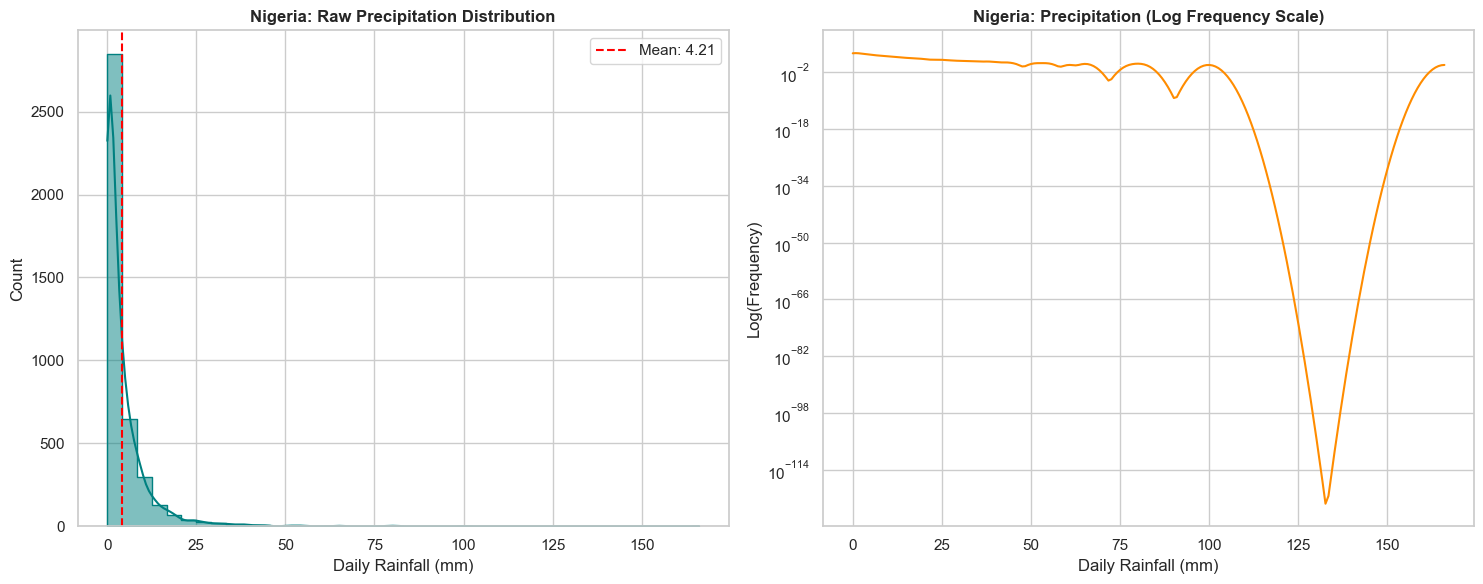

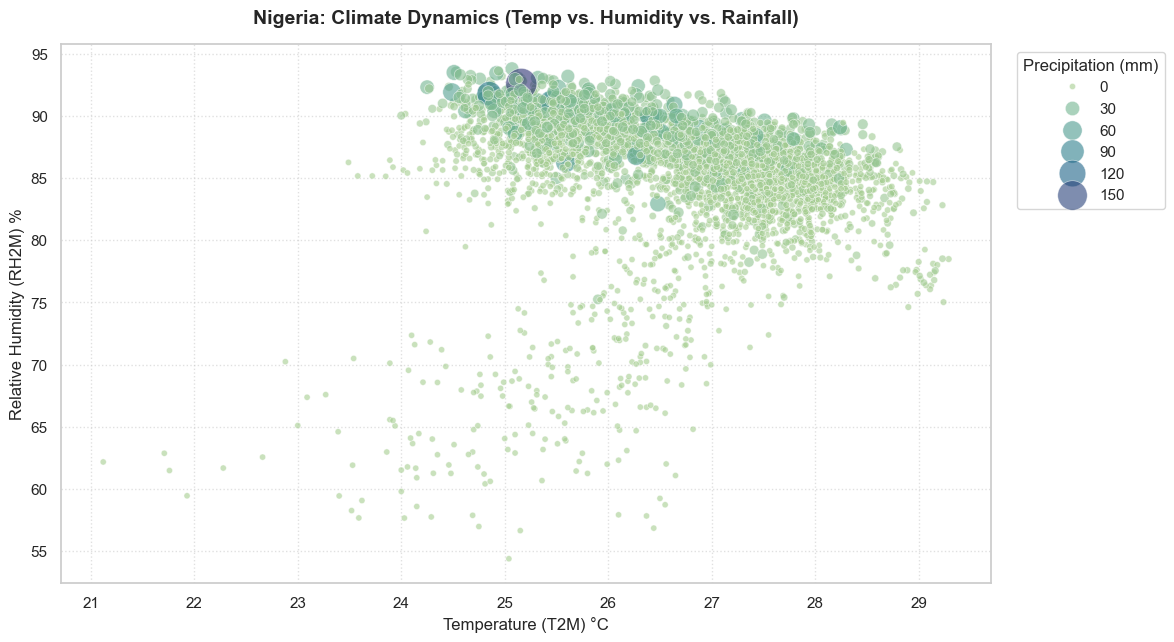

In [52]:
# Rainfall Distribution & Climate Dynamics
# 1. Setup specific aesthetic
sns.set_style("whitegrid")

# Compare Raw vs. Log Transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw Distribution with Mean line
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, ax=ax1, color='teal', element="step")
ax1.axvline(df['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df["PRECTOTCORR"].mean():.2f}')
ax1.set_title("Nigeria: Raw Precipitation Distribution", fontweight='bold')
ax1.set_xlabel("Daily Rainfall (mm)")
ax1.legend()

# Plot 2: Log Scale (Better for viewing extreme events)
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, ax=ax2, color='darkorange', log_scale=(False, True))
ax2.set_title("Nigeria: Precipitation (Log Frequency Scale)", fontweight='bold')
ax2.set_xlabel("Daily Rainfall (mm)")
ax2.set_ylabel("Log(Frequency)")

plt.tight_layout()
plt.show()

# --- Plot 2: Advanced Bubble Chart (Multivariate Analysis) ---
plt.figure(figsize=(12, 7))

# Using 'crest' or 'magma' palette for a more sophisticated look
scatter = sns.scatterplot(data=df, x='T2M', y='RH2M', 
                         size='PRECTOTCORR', hue='PRECTOTCORR',
                         palette='crest', sizes=(20, 500), 
                         alpha=0.6, edgecolor='white', linewidth=0.5)

plt.title("Nigeria: Climate Dynamics (Temp vs. Humidity vs. Rainfall)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Temperature (T2M) °C")
plt.ylabel("Relative Humidity (RH2M) %")

# Clean up the legend
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Precipitation (mm)", frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

This final section of the analysis examines the distribution patterns and multivariate interactions of the Nigerian climate dataset. Here is the professional **Markdown Analysis** for your `eda-nigeria.ipynb` notebook.

***

### 🌧️ Distribution Analysis: Precipitation and Multivariate Dynamics

#### 1. Precipitation Distribution (Histogram Analysis)
*   **Distribution Shape:** The raw precipitation histogram reveals an **extremely right-skewed** distribution. The vast majority of daily records show little to no rainfall (concentrated near 0), while the "tail" extends toward the 160mm+ range. 
*   **Log-Scale Insights:** Because the mean rainfall is low (**4.21mm**), the raw chart hides the intensity of extreme events. By applying a **log-frequency scale** (right chart), we can see that while intense rainfall (125mm - 150mm+) is statistically rare, it follows a distinct stochastic pattern. These "heavy tail" events represent the vital monsoon pulses that sustain Nigeria's water cycle.
*   **Interpretation:** The low daily mean is a poor indicator of climatic risk; the distribution proves that Nigeria’s water supply is dominated by infrequent, high-intensity pulses rather than steady daily accumulation.

#### 2. Multivariate Climate Dynamics (Bubble Chart)
The bubble chart visualizes the complex interaction between **Temperature (T2M)**, **Relative Humidity (RH2M)**, and **Precipitation (Bubble Size)**.
*   **The "Rain Window":** Significant rainfall events (the largest, dark bubbles) are not randomly occurring. They are tightly clustered in a specific "Trigger Window" where **Relative Humidity is above 85%** and **Temperature is between 24°C and 26.5°C**.
*   **Moisture Threshold:** There is a visible "humidity floor" around 80%; below this level, even at optimal temperatures, significant rainfall (bubbles) is almost non-existent. This confirms that high relative humidity is a primary physical prerequisite for precipitation in the Nigerian tropical context.
*   **Thermal Barrier:** Notice that as temperatures climb toward 29°C+, the bubbles shrink. In Nigeria, extreme heat often correlates with dry, stable air, while the "cooler" monsoon phases align with the humid, rain-bearing ITCZ movement.
***

## 📚 References & Self-Learning
During this analysis, the following resources were consulted to ensure best practices in climate data handling:
1. **NASA POWER Documentation:** Understood the -999 sentinel value and parameter definitions (T2M, PRECTOTCORR).
2. **Seaborn Documentation:** Utilized the `regplot` and `heatmap` masking techniques for clearer visualization.
3. **Scipy Stats:** Implemented `zscore` for statistical outlier detection.
4. **Python Pathlib:** Implemented for cross-platform file management and robust export paths.